In [129]:
import zipfile
import glob
import os
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path
import re 
import shutil

# Create clean temp dir in cwd (avoids OneDrive path issues)
temp_base = Path('temp_gmtds_extract')
temp_base.mkdir(exist_ok=True)
os.getcwd()

'C:\\Users\\Bruno\\OneDrive - CIMA Foundation\\Documenti\\Python_Scripts\\oil-spills'

In [23]:
from sklearn.cluster import DBSCAN

class HotspotConfig:
    """Runtime configuration for hotspot extraction."""

    lon_min: float = 40.0
    lon_max: float = 45.0
    lat_min: float = 10.0
    lat_max: float = 14.0
    percentile_threshold: float = 90.0
    min_high_pixels: int = 10
    dbscan_eps: float = 0.1
    dbscan_min_samples: int = 5
    
def extract_hotspots_from_raster(
    density: np.ndarray,
    transform: rasterio.Affine,
    year: str,
    month: str,
    source_file: str,
    cfg: HotspotConfig,
) -> list[dict[str, float | int | str]]:
    """Detect and cluster high-density pixels from a single monthly raster."""
    valid = density[~np.isnan(density)]
    if valid.size == 0:
        return []

    threshold = np.percentile(valid, cfg.percentile_threshold)
    high_mask = density > threshold

    lon, lat = pixel_centers(transform, density.shape)
    region_mask = (
        (lon >= cfg.lon_min)
        & (lon <= cfg.lon_max)
        & (lat >= cfg.lat_min)
        & (lat <= cfg.lat_max)
    )

    candidate_mask = high_mask & region_mask & ~np.isnan(density)
    rows, cols = np.where(candidate_mask)
    if rows.size < cfg.min_high_pixels:
        return []

    coords = np.column_stack((lon[rows, cols], lat[rows, cols]))
    densities = density[rows, cols]
    labels = DBSCAN(eps=cfg.dbscan_eps, min_samples=cfg.dbscan_min_samples).fit(coords).labels_

    hotspots: list[dict[str, float | int | str]] = []
    for label in sorted(set(labels)):
        if label == -1:
            continue

        cluster_mask = labels == label
        cluster_lon = coords[cluster_mask, 0]
        cluster_lat = coords[cluster_mask, 1]
        cluster_dens = densities[cluster_mask]

        hotspots.append(
            {
                "year": year,
                "month": month,
                "cluster_id": int(label),
                "lon": float(np.mean(cluster_lon)),
                "lat": float(np.mean(cluster_lat)),
                "mean_density": float(np.mean(cluster_dens)),
                "max_density": float(np.max(cluster_dens)),
                "n_pixels": int(cluster_lon.size),
                "source_file": source_file,
            }
        )

    return hotspots

In [10]:
import rasterio
import numpy as np
with rasterio.open(r'C:\Users\Bruno\OneDrive - CIMA Foundation\Documenti\UNDP_Djibouti\UN projects - 2026_UNDP Djibouti\DATA\00_Hazard\MarinePollution\grid_float_Tankers_2023_12_converted.tif') as src:
            density = src.read(1, masked=True).filled(np.nan).astype(float)
            print(np.nanmax(density),src.transform)

1085.514404296875 | 0.01, 0.00, 35.48|
| 0.00,-0.01, 18.31|
| 0.00, 0.00, 1.00| GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]


In [16]:
def pixel_centers(transform: rasterio.Affine, shape: tuple[int, int]) -> tuple[np.ndarray, np.ndarray]:
    """Create longitude/latitude arrays for raster cell centers."""
    height, width = shape
    x_coords = transform.c + (np.arange(width) + 0.5) * transform.a
    y_coords = transform.f + (np.arange(height) + 0.5) * transform.e
    return np.meshgrid(x_coords, y_coords)

In [28]:
import rasterio
from pathlib import Path


data_dir = Path(r'C:\Users\Bruno\OneDrive - CIMA Foundation\Documenti\UNDP_Djibouti\UN projects - 2026_UNDP Djibouti\DATA\00_Hazard\MarinePollution')

# Test your two rasters
rasters = [
    'grid_float_Tankers_2016_05_converted.tif',  # Replace with your filenames
    'grid_float_Tankers_2023_12_converted.tif'
]

hotspots: list[dict[str, float | int | str]] = []
cfg= HotspotConfig
for tif in rasters:
    path = data_dir / tif
    year=tif.split('_')[3]
    month = tif.split('_')[4]
    if path.exists():
        with rasterio.open(path) as src:
            density = src.read(1, masked=True).filled(np.nan).astype(float)
            transform = src.transform
            hotspots.extend(
                extract_hotspots_from_raster(
                    density=density,
                    transform=transform,
                    year=year,
                    month=month,
                    source_file=tif,
                    cfg=cfg,
                )
            )
hotspots

[{'year': '2016',
  'month': '05',
  'cluster_id': 0,
  'lon': 43.5432178711413,
  'lat': 12.786268046031596,
  'mean_density': 1.4863741124224779,
  'max_density': 5.314532279968262,
  'n_pixels': 2456,
  'source_file': 'grid_float_Tankers_2016_05_converted.tif'},
 {'year': '2016',
  'month': '05',
  'cluster_id': 1,
  'lon': 44.94209065650018,
  'lat': 12.741817438276087,
  'mean_density': 163.208519866592,
  'max_density': 825.4802856445312,
  'n_pixels': 19,
  'source_file': 'grid_float_Tankers_2016_05_converted.tif'},
 {'year': '2016',
  'month': '05',
  'cluster_id': 2,
  'lon': 43.114464309753906,
  'lat': 11.6864531731507,
  'mean_density': 31.930362911838472,
  'max_density': 319.4727783203125,
  'n_pixels': 66,
  'source_file': 'grid_float_Tankers_2016_05_converted.tif'},
 {'year': '2016',
  'month': '05',
  'cluster_id': 3,
  'lon': 44.96636583035513,
  'lat': 10.445411954350455,
  'mean_density': 148.54750433293256,
  'max_density': 374.0328674316406,
  'n_pixels': 11,
  's

43.5432178711413 12.786268046031596 1.4863741124224779 5.314532279968262
44.94209065650018 12.741817438276087 163.208519866592 825.4802856445312
43.114464309753906 11.6864531731507 31.930362911838472 319.4727783203125
44.96636583035513 10.445411954350455 148.54750433293256 374.0328674316406
43.56683858328005 12.767664086117826 4.680293421566068 12.73474407196045
43.204654585807155 13.35221906477785 298.0128684043884 738.0740966796875
43.123821203436556 11.65583773022252 82.96711030034791 942.25439453125
44.96365272268899 10.439245800563768 126.06384210586548 409.859619140625


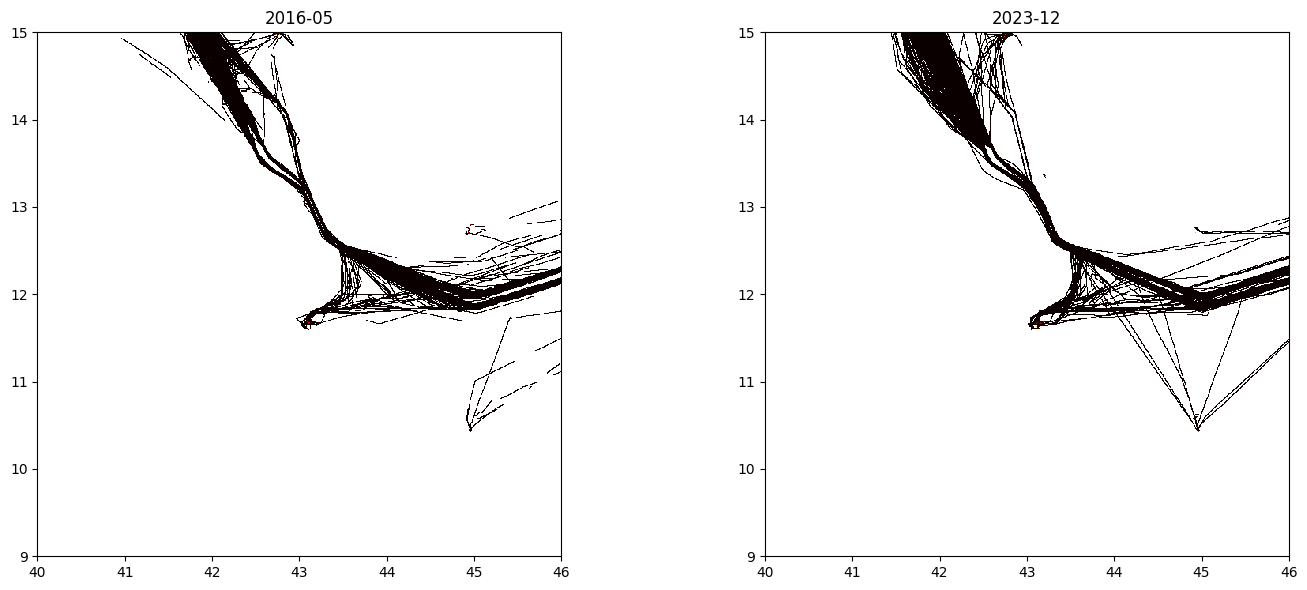

In [32]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import numpy as np
from pathlib import Path

data_dir = Path(r'C:\Users\Bruno\OneDrive - CIMA Foundation\Documenti\UNDP_Djibouti\UN projects - 2026_UNDP Djibouti\DATA\00_Hazard\MarinePollution')

rasters = [
    'grid_float_Tankers_2016_05_converted.tif',
    'grid_float_Tankers_2023_12_converted.tif'
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, tif in enumerate(rasters):
    path = data_dir / tif
    year, month = tif.split('_')[3], tif.split('_')[4]
    
    # Filter hotspots for THIS raster only
    tif_hotspots = [hs for hs in hotspots if hs['year'] == year and hs['month'] == month]
    
    with rasterio.open(path) as src:
        ax = axes[i]
        show(src, ax=ax, cmap='hot', interpolation='nearest')
        ax.set_title(f'{year}-{month}')
        
        # Plot ONLY this raster's hotspots
        # for hs in tif_hotspots:
        #     ax.plot(hs['lon'], hs['lat'], 'ro', markersize=10, markeredgecolor='white')
        for hs in tif_hotspots:
            print(hs["lon"], hs["lat"], hs["mean_density"], hs["max_density"])
        
        ax.set_xlim(40, 46)
        ax.set_ylim(9, 15)

plt.tight_layout()
plt.show()

#### TESTS FROM CODEX script
1. OSCAR data download

In [1]:
from datetime import date, datetime
from pathlib import Path
import getpass, os

from oilspill_risk.models import StudyArea, infer_study_area_from_hotspots, OscarDownloadConfig
from oilspill_risk.oscar_workflow import download_oscar_for_periods
from oilspill_risk.periods import seasonal_periods
from oilspill_risk.gridding import standardize_oscar_uv_netcdf, export_oscar_uv_geotiff

In [2]:
passEarth = getpass.getpass("Enter passphrase for Earthdata login: ")
os.environ["EARTHDATA_USERNAME"] = "bcolavitto"
os.environ["EARTHDATA_PASSWORD"] = passEarth

Enter passphrase for Earthdata login:  ········


In [8]:
passEarth

'd0wnLOAD3R11235**'

In [2]:
area = infer_study_area_from_hotspots(Path(r"C:\Users\Bruno\OneDrive - CIMA Foundation\Documenti\UNDP_Djibouti\UN projects - 2026_UNDP Djibouti\DATA\00_Hazard\MarinePollution\marine-traffic\gmtds_tanker_hotspots_multi.csv"), pad_deg=0.7)

periods = seasonal_periods(
    start_date=datetime(2022, 1, 1, 0, 0, 0).strftime('%Y-%m-%dT%H:%M:%SZ'), #dates should be strings in YYYYMMDDhhmmssZ format
    end_date=datetime(2022, 6, 30, 23, 59, 59).strftime('%Y-%m-%dT%H:%M:%SZ'),
    season_length_months=3,
)
cfg = OscarDownloadConfig(
    output_dir=Path(r"C:\Users\Bruno\OneDrive - CIMA Foundation\Documenti\UNDP_Djibouti\UN projects - 2026_UNDP Djibouti\DATA\00_Hazard\MarinePollution"),
    podaac_collection="OSCAR_L4_OC_FINAL_V2.0",
)
area, periods, cfg

(StudyArea(lon_min=41.50803970311112, lon_max=45.69349690701655, lat_min=9.72568026223306, lat_max=14.679851304878618),
 [(datetime.date(2022, 1, 1), datetime.date(2022, 3, 31), 'S1'),
  (datetime.date(2022, 4, 1), datetime.date(2022, 6, 30), 'S2')],
 OscarDownloadConfig(output_dir=WindowsPath('C:/Users/Bruno/OneDrive - CIMA Foundation/Documenti/UNDP_Djibouti/UN projects - 2026_UNDP Djibouti/DATA/00_Hazard/MarinePollution'), podaac_collection='OSCAR_L4_OC_FINAL_V2.0', u_var='u', v_var='v'))

In [ ]:
downloaded = download_oscar_for_periods(cfg, periods, area, standardize=True)

In [9]:
import xarray as xr
# import rioxarray as rio

for raw_nc in sorted((Path("files")).glob("oscar_currents_final_*.nc")): 
    date_id = raw_nc.stem.rsplit("_", 1)[-1]
    clipped_nc = raw_nc.with_name(f"oscar_uv_std_{date_id}.nc")
    standardize_oscar_uv_netcdf(raw_nc, clipped_nc, None)
    export_oscar_uv_geotiff(clipped_nc, raw_nc.parent, None)

C:\Users\Bruno\OneDrive - CIMA Foundation\Documenti\Python_Scripts\oilspills-risk\oilspill_risk\gridding.py:113: UserWarning: rename 'longitude' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds = ds.rename(rename)
C:\Users\Bruno\OneDrive - CIMA Foundation\Documenti\Python_Scripts\oilspills-risk\oilspill_risk\gridding.py:113: UserWarning: rename 'latitude' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds = ds.rename(rename)
C:\Users\Bruno\OneDrive - CIMA Foundation\Documenti\Python_Scripts\oilspills-risk\oilspill_risk\gridding.py:113: UserWarning: rename 'longitude' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds = ds.rename(rename)
C:\Users\Bruno\OneDrive - CIMA Foundation\Documenti\Python_Scripts\oilspills-risk\oilspil

In [11]:
from oilspill_risk.trajectory import current_field_from_geotiff, current_field_from_netcdf

# NetCDF workflow, useful when retaining the time dimension
currents_from_netcdf = current_field_from_netcdf(cfg.output_dir / 'oscar_uv_std_clip_20200121.nc')

(<GeoAxes: title={'center': 'Marine current orientation and intensity'}, xlabel='Longitude', ylabel='Latitude'>,
 <matplotlib.collections.PathCollection at 0x1587d7e8f10>)

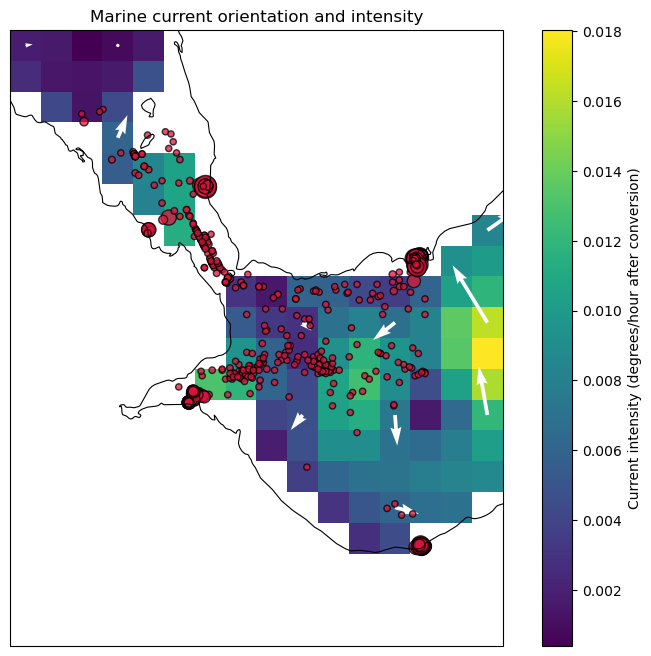

In [3]:
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

from pathlib import Path
from oilspill_risk.mapping import plot_current_orientation_intensity, plot_hotspots

ax, mesh, quiver = plot_current_orientation_intensity(
    u_tif=Path(cfg.output_dir / "oscar_files_ready/oscar_uv_std_clip_S1_20220101_u.tif"),
    v_tif=Path(cfg.output_dir / "oscar_files_ready/oscar_uv_std_clip_S1_20220101_v.tif"),
    stride=3,
    add_coastlines=True,
)

plot_hotspots(cfg.output_dir / "marine-traffic/gmtds_tanker_hotspots_multi.csv", ax=ax, density_col="mean_density")

In [4]:
from pathlib import Path
from oilspill_risk.coastlines import coast_points_from_shapefile
from oilspill_risk.exposure import (
    aggregate_exposure_probabilities_for_periods,
    exposure_from_netcdf,
    write_exposure_geotiff,
)

coast_points = coast_points_from_shapefile(
    cfg.output_dir / "djibouti_ville_coast.shp",
    spacing=0.01,  # decimal degrees when working with EPSG:4326 OSCAR grids
    target_crs="EPSG:4326",
    segment_id_col="segment_id",
    # selected_segments={"djibouti", "yemen"},
)

daily_results = [
    exposure_from_netcdf(
        nc_path,
        coast_points,
        alpha=2.0,
        include_speed=True,
        current_kwargs={"input_units": "m/s"},
    )
    for _, _, period_id in periods
    for nc_path in sorted((cfg.output_dir / "oscar_files_ready").glob(f"oscar_uv_std_clip_{period_id}_*.nc"))
]

period_results = aggregate_exposure_probabilities_for_periods(daily_results, periods)
for period_id, result in period_results.items():
    write_exposure_geotiff(result, cfg.output_dir / f"probability_maps/coastward_probability_{period_id}.tif")

C:\Users\Bruno\OneDrive - CIMA Foundation\Documenti\Python_Scripts\oilspills-risk\oilspill_risk\exposure.py:208: RuntimeWarning: Mean of empty slice
  probability = np.nanmean(np.stack([result.probability for result in results]), axis=0)
C:\Users\Bruno\OneDrive - CIMA Foundation\Documenti\Python_Scripts\oilspills-risk\oilspill_risk\exposure.py:209: RuntimeWarning: Mean of empty slice
  alignment = np.nanmean(np.stack([result.alignment for result in results]), axis=0)
C:\Users\Bruno\OneDrive - CIMA Foundation\Documenti\Python_Scripts\oilspills-risk\oilspill_risk\exposure.py:210: RuntimeWarning: Mean of empty slice
  speed = np.nanmean(np.stack([result.speed for result in results]), axis=0)
